# Home Credit Default Risk - Analyse exploratoire et préparation des données

In [1]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
import warnings
import pickle
import json
from datetime import datetime
from sklearn.preprocessing import LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
import mlflow
import mlflow.sklearn
import mlflow.xgboost
import mlflow.lightgbm
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.metrics import roc_auc_score, accuracy_score, recall_score, precision_score, f1_score, confusion_matrix, roc_curve
from sklearn.preprocessing import StandardScaler
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

# Configuration MLflow
mlflow.set_tracking_uri("file:./mlruns")

# Activation de l'autolog pour capturer automatiquement les métriques
mlflow.xgboost.autolog(log_model_signatures=True, log_input_examples=False)
mlflow.lightgbm.autolog(log_model_signatures=True, log_input_examples=False)
mlflow.sklearn.autolog(log_model_signatures=False)  # Désactivé pour Dummy/LogReg (trop simple)

# Version des données pour la reproductibilité
DATA_VERSION = "v1.0"
RANDOM_STATE = 42

warnings.filterwarnings('ignore')
plt.style.use('default')
sns.set_palette("husl")

print(f"✓ MLflow configuré avec autolog activé")
print(f"✓ Version des données: {DATA_VERSION}")
print(f"✓ Random state: {RANDOM_STATE}")

✓ MLflow configuré avec autolog activé
✓ Version des données: v1.0
✓ Random state: 42


## 1. Chargement et inspection des données

- **application_train/test**: Table principale contenant les informations sur les demandes de crédit
- **bureau**: Historique des crédits précédents auprès d'autres institutions financières
- **bureau_balance**: Historique mensuel des crédits du bureau
- **previous_application**: Demandes de crédit antérieures chez Home Credit
- **credit_card_balance**: Historique mensuel des cartes de crédit
- **POS_CASH_balance**: Historique mensuel des prêts POS et cash
- **installments_payments**: Historique des paiements des échéances

In [2]:
app_train = pd.read_csv('data/application_train.csv')
app_test = pd.read_csv('data/application_test.csv')
bureau = pd.read_csv('data/bureau.csv')
bureau_balance = pd.read_csv('data/bureau_balance.csv')
credit_card = pd.read_csv('data/credit_card_balance.csv')
pos_cash = pd.read_csv('data/POS_CASH_balance.csv')
previous_app = pd.read_csv('data/previous_application.csv')
installments = pd.read_csv('data/installments_payments.csv')

### 1.1 Inspection des dimensions et colonnes

Nous affichons les dimensions de chaque table pour comprendre la volumétrie des données.
Cela nous permet d'identifier:
- Les tables principales (peu de lignes, beaucoup de colonnes)
- Les tables d'historique (beaucoup de lignes, moins de colonnes)
- La complexité du dataset et les besoins en mémoire

In [3]:
datasets = {
    'application_train': app_train,
    'application_test': app_test,
    'bureau': bureau,
    'bureau_balance': bureau_balance,
    'credit_card_balance': credit_card,
    'POS_CASH_balance': pos_cash,
    'previous_application': previous_app,
    'installments_payments': installments
}

for name, df in datasets.items():
    print(f"\n{name} : {df.shape}")



application_train : (307511, 122)

application_test : (48744, 121)

bureau : (1716428, 17)

bureau_balance : (27299925, 3)

credit_card_balance : (3840312, 23)

POS_CASH_balance : (10001358, 8)

previous_application : (1670214, 37)

installments_payments : (13605401, 8)


In [4]:
display(app_train.head())

print(f"Types de colonnes:")
print(app_train.dtypes.value_counts())

print(f"Colonnes:")
print(app_train.columns.tolist())

,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
3,100006,0,Cash loans,F,N,Y,0,135000.0,312682.5,29686.5,...,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
4,100007,0,Cash loans,M,N,Y,0,121500.0,513000.0,21865.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0


Types de colonnes:
float64    65
int64      41
object     16
Name: count, dtype: int64
Colonnes:
['SK_ID_CURR', 'TARGET', 'NAME_CONTRACT_TYPE', 'CODE_GENDER', 'FLAG_OWN_CAR', 'FLAG_OWN_REALTY', 'CNT_CHILDREN', 'AMT_INCOME_TOTAL', 'AMT_CREDIT', 'AMT_ANNUITY', 'AMT_GOODS_PRICE', 'NAME_TYPE_SUITE', 'NAME_INCOME_TYPE', 'NAME_EDUCATION_TYPE', 'NAME_FAMILY_STATUS', 'NAME_HOUSING_TYPE', 'REGION_POPULATION_RELATIVE', 'DAYS_BIRTH', 'DAYS_EMPLOYED', 'DAYS_REGISTRATION', 'DAYS_ID_PUBLISH', 'OWN_CAR_AGE', 'FLAG_MOBIL', 'FLAG_EMP_PHONE', 'FLAG_WORK_PHONE', 'FLAG_CONT_MOBILE', 'FLAG_PHONE', 'FLAG_EMAIL', 'OCCUPATION_TYPE', 'CNT_FAM_MEMBERS', 'REGION_RATING_CLIENT', 'REGION_RATING_CLIENT_W_CITY', 'WEEKDAY_APPR_PROCESS_START', 'HOUR_APPR_PROCESS_START', 'REG_REGION_NOT_LIVE_REGION', 'REG_REGION_NOT_WORK_REGION', 'LIVE_REGION_NOT_WORK_REGION', 'REG_CITY_NOT_LIVE_CITY', 'REG_CITY_NOT_WORK_CITY', 'LIVE_CITY_NOT_WORK_CITY', 'ORGANIZATION_TYPE', 'EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3', 'APARTMENTS_A

### 1.2 Identification des clés de jointure

Les tables sont reliées entre elles par des clés primaires et étrangères:
- **SK_ID_CURR**: Identifiant unique du client (clé primaire dans application_train/test)
- **SK_ID_PREV**: Identifiant des demandes de crédit antérieures
- **SK_ID_BUREAU**: Identifiant des crédits du bureau

**Structure hiérarchique:**
- Un client (SK_ID_CURR) peut avoir plusieurs demandes antérieures (SK_ID_PREV)
- Un client peut avoir plusieurs crédits dans le bureau (SK_ID_BUREAU)
- Chaque demande antérieure peut avoir plusieurs lignes dans credit_card_balance, POS_CASH_balance, installments_payments

In [5]:
for name, df in datasets.items():
    key_cols = [col for col in df.columns if 'SK_ID' in col]
    print(f"\n{name}:")
    for col in key_cols:
        n_unique = df[col].nunique()
        n_total = len(df)
        print(f"  - {col} : {n_unique} valeurs uniques / {n_total} lignes")



application_train:
  - SK_ID_CURR : 307511 valeurs uniques / 307511 lignes

application_test:
  - SK_ID_CURR : 48744 valeurs uniques / 48744 lignes

bureau:
  - SK_ID_CURR : 305811 valeurs uniques / 1716428 lignes
  - SK_ID_BUREAU : 1716428 valeurs uniques / 1716428 lignes

bureau_balance:
  - SK_ID_BUREAU : 817395 valeurs uniques / 27299925 lignes

credit_card_balance:
  - SK_ID_PREV : 104307 valeurs uniques / 3840312 lignes
  - SK_ID_CURR : 103558 valeurs uniques / 3840312 lignes

POS_CASH_balance:
  - SK_ID_PREV : 936325 valeurs uniques / 10001358 lignes
  - SK_ID_CURR : 337252 valeurs uniques / 10001358 lignes

previous_application:
  - SK_ID_PREV : 1670214 valeurs uniques / 1670214 lignes
  - SK_ID_CURR : 338857 valeurs uniques / 1670214 lignes

installments_payments:
  - SK_ID_PREV : 997752 valeurs uniques / 13605401 lignes
  - SK_ID_CURR : 339587 valeurs uniques / 13605401 lignes


## 2. Analyse de la variable cible

La variable **TARGET** indique si un client a eu des difficultés de paiement:
- **0**: Client a remboursé son crédit sans difficultés (bon payeur)
- **1**: Client a eu des difficultés de paiement (défaut de paiement)

Cette analyse est cruciale pour:
- Identifier un éventuel déséquilibre des classes
- Comprendre la distribution de la variable à prédire
- Adapter la stratégie de modélisation en conséquence (sampling, métriques adaptées, etc.)

  Classe 0 (Bon payeur) : 282686 (91.92711805431351%)
  Classe 1 (Défaut paiement) : 24825 ( 8.07%)


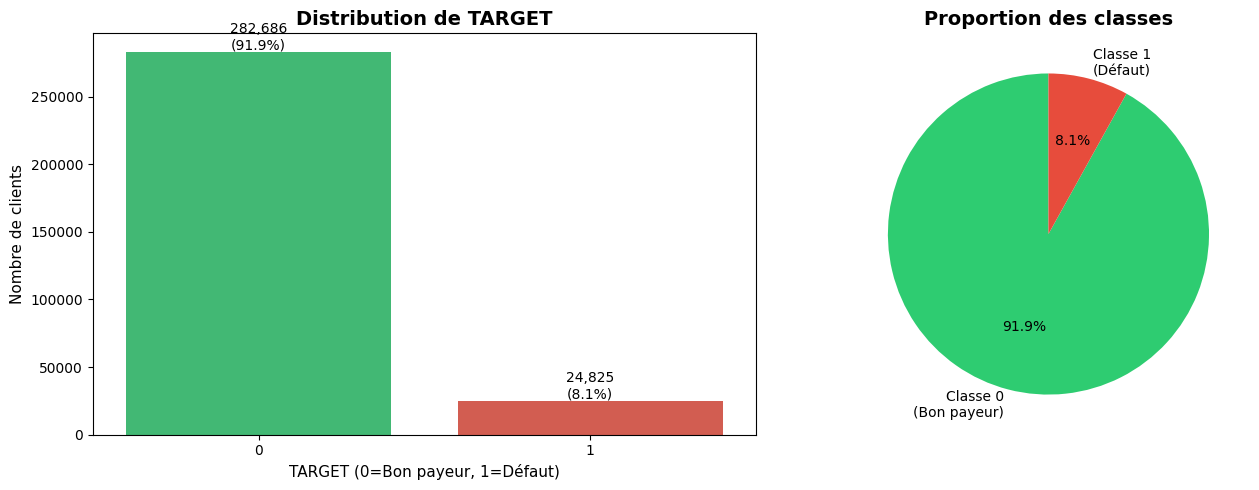

In [6]:
target_counts = app_train['TARGET'].value_counts()
target_pct = app_train['TARGET'].value_counts(normalize=True) * 100

print(f"  Classe 0 (Bon payeur) : {target_counts[0]} ({target_pct[0]}%)")
print(f"  Classe 1 (Défaut paiement) : {target_counts[1]} ({target_pct[1]:>5.2f}%)")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.countplot(data=app_train, x='TARGET', ax=axes[0], palette=['#2ecc71', '#e74c3c'])
axes[0].set_title('Distribution de TARGET', fontsize=14, fontweight='bold')
axes[0].set_xlabel('TARGET (0=Bon payeur, 1=Défaut)', fontsize=11)
axes[0].set_ylabel('Nombre de clients', fontsize=11)
for p in axes[0].patches:
    axes[0].text(p.get_x() + p.get_width()/2., p.get_height(), 
                 f'{int(p.get_height()):,}\n({100*p.get_height()/len(app_train):.1f}%)',
                 ha='center', va='bottom')

colors = ['#2ecc71', '#e74c3c']
axes[1].pie(target_counts, labels=['Classe 0\n(Bon payeur)', 'Classe 1\n(Défaut)'], 
            autopct='%1.1f%%', colors=colors, startangle=90)
axes[1].set_title('Proportion des classes', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

## 3. Analyse des valeurs manquantes


**Stratégies selon le taux de valeurs manquantes:**
- **> 70%**: Suppression de la colonne (trop peu d'information)
- **50-70%**: Évaluation au cas par cas selon l'importance de la feature
- **10-50%**: Imputation ou création d'une feature binaire "valeur_manquante"
- **< 10%**: Imputation simple (médiane, moyenne, mode)

In [7]:
def analyze_missing_values(df, name):
    missing = df.isnull().sum()
    missing_pct = (missing / len(df)) * 100
    missing_df = pd.DataFrame({
        'Colonnes': missing.index,
        'Valeurs_manquantes': missing.values,
        'Pourcentage': missing_pct.values
    })
    missing_df = missing_df[missing_df['Valeurs_manquantes'] > 0].sort_values('Pourcentage', ascending=False)
    
    print(f"{name}")
    print(f"Total colonnes avec valeurs manquantes: {len(missing_df)} / {len(df.columns)}")
    
    if len(missing_df) > 0:
        print(f"\nTop 10 colonnes avec le plus de valeurs manquantes:")
        print(missing_df.head(10).to_string(index=False))

        high = len(missing_df[missing_df['Pourcentage'] > 50])
        medium = len(missing_df[(missing_df['Pourcentage'] > 10) & (missing_df['Pourcentage'] <= 50)])
        low = len(missing_df[missing_df['Pourcentage'] <= 10])
        
        print(f"\nCatégorisation:")
        print(f"  > 50% manquant : {high} colonnes")
        print(f"  10-50% manquant: {medium} colonnes")
        print(f"  < 10% manquant : {low} colonnes")
    else:
        print("Aucune valeur manquante")
    
    return missing_df

missing_train = analyze_missing_values(app_train, "APPLICATION_TRAIN")

APPLICATION_TRAIN
Total colonnes avec valeurs manquantes: 67 / 122

Top 10 colonnes avec le plus de valeurs manquantes:
                Colonnes  Valeurs_manquantes  Pourcentage
         COMMONAREA_MEDI              214865    69.872297
         COMMONAREA_MODE              214865    69.872297
          COMMONAREA_AVG              214865    69.872297
NONLIVINGAPARTMENTS_MODE              213514    69.432963
NONLIVINGAPARTMENTS_MEDI              213514    69.432963
 NONLIVINGAPARTMENTS_AVG              213514    69.432963
      FONDKAPREMONT_MODE              210295    68.386172
    LIVINGAPARTMENTS_AVG              210199    68.354953
   LIVINGAPARTMENTS_MEDI              210199    68.354953
   LIVINGAPARTMENTS_MODE              210199    68.354953

Catégorisation:
  > 50% manquant : 41 colonnes
  10-50% manquant: 16 colonnes
  < 10% manquant : 10 colonnes


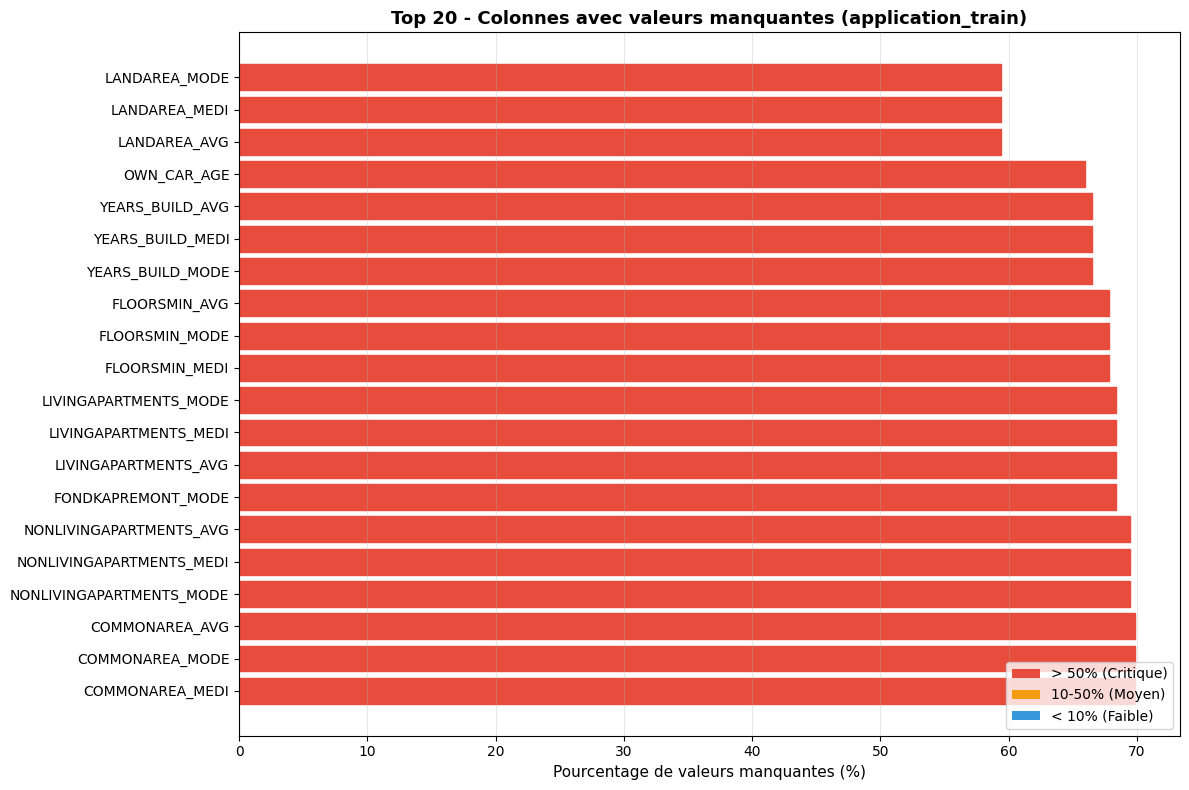

In [8]:
if len(missing_train) > 0:
    fig, ax = plt.subplots(figsize=(12, 8))
    top_missing = missing_train.head(20)
    
    bars = ax.barh(top_missing['Colonnes'], top_missing['Pourcentage'])

    for i, (bar, pct) in enumerate(zip(bars, top_missing['Pourcentage'])):
        if pct > 50:
            bar.set_color('#e74c3c')
        elif pct > 10:
            bar.set_color('#f39c12')
        else:
            bar.set_color('#3498db')
    
    ax.set_xlabel('Pourcentage de valeurs manquantes (%)', fontsize=11)
    ax.set_title('Top 20 - Colonnes avec valeurs manquantes (application_train)', fontsize=13, fontweight='bold')
    ax.grid(axis='x', alpha=0.3)

    from matplotlib.patches import Patch
    legend_elements = [Patch(facecolor='#e74c3c', label='> 50% (Critique)'),
                      Patch(facecolor='#f39c12', label='10-50% (Moyen)'),
                      Patch(facecolor='#3498db', label='< 10% (Faible)')]
    ax.legend(handles=legend_elements, loc='lower right')
    
    plt.tight_layout()
    plt.show()

## 4. Vérification des doublons

La vérification des doublons est essentielle pour:
- **Lignes complètement identiques**
- **Doublons sur la clé primaire**

**Interprétation:**
- Les doublons sur SK_ID_CURR dans les tables secondaires (bureau, previous_application, etc.) sont **normaux** car:
  - Un client peut avoir plusieurs crédits antérieurs
  - Un crédit peut avoir plusieurs échéances de paiement
  - C'est pourquoi nous devons **agréger** ces tables avant la jointure

- Les doublons dans application_train seraient **problématiques** car chaque ligne devrait représenter un client unique

In [9]:
for name, df in datasets.items():
    n_duplicates = df.duplicated().sum()
    pct_duplicates = (n_duplicates / len(df)) * 100
    
    key_cols = [col for col in df.columns if 'SK_ID' in col and col.endswith('_CURR') or col.endswith('_PREV') or col == 'SK_ID_BUREAU']
    
    if key_cols:
        key_col = key_cols[0]
        n_dup_keys = df[key_col].duplicated().sum()
        status_key = "pas de doublons" if n_dup_keys == 0 else "doublons detecté"
    else:
        key_col = None
        n_dup_keys = "N/A"
        status_key = ""
    
    status = "pas de doublons" if n_duplicates == 0 else "doublons detecté"
    
    print(f"\n{name}:")
    print(f"  Lignes dupliquées {status} {n_duplicates} ({pct_duplicates}%)")
    if key_col:
        print(f"  Doublons sur {key_col} : {status_key} {n_dup_keys}")



application_train:
  Lignes dupliquées pas de doublons 0 (0.0%)
  Doublons sur SK_ID_CURR : pas de doublons 0

application_test:
  Lignes dupliquées pas de doublons 0 (0.0%)
  Doublons sur SK_ID_CURR : pas de doublons 0

bureau:
  Lignes dupliquées pas de doublons 0 (0.0%)
  Doublons sur SK_ID_CURR : doublons detecté 1410617

bureau_balance:
  Lignes dupliquées pas de doublons 0 (0.0%)
  Doublons sur SK_ID_BUREAU : doublons detecté 26482530

credit_card_balance:
  Lignes dupliquées pas de doublons 0 (0.0%)
  Doublons sur SK_ID_PREV : doublons detecté 3736005

POS_CASH_balance:
  Lignes dupliquées pas de doublons 0 (0.0%)
  Doublons sur SK_ID_PREV : doublons detecté 9065033

previous_application:
  Lignes dupliquées pas de doublons 0 (0.0%)
  Doublons sur SK_ID_PREV : pas de doublons 0

installments_payments:
  Lignes dupliquées pas de doublons 0 (0.0%)
  Doublons sur SK_ID_PREV : doublons detecté 12607649


## 5. Jointure des données et création du dataframe consolidé


1. **Agréger les tables secondaires** au niveau client (SK_ID_CURR)
   - Chaque client doit avoir **une seule ligne** dans le dataset final
   - Les tables avec plusieurs lignes par client doivent être résumées en features agrégées

2. **Fusionner avec la table principale** (application_train)
   - Utiliser des jointures LEFT pour conserver tous les clients de application_train
   - Même si un client n'a pas d'historique dans les tables secondaires

**Méthodes d'agrégation utilisées:**
- **count**: Nombre d'occurrences (ex: nombre de crédits antérieurs)
- **sum**: Somme totale (ex: dette totale)
- **mean**: Moyenne (ex: montant moyen des crédits)
- **min/max**: Valeurs extrêmes (ex: retard maximum)
- **lambda functions**: Calculs personnalisés (ex: nombre de crédits actifs)

In [10]:
bureau_agg = bureau.groupby('SK_ID_CURR').agg({
    'SK_ID_BUREAU': 'count',  # Nombre de crédits antérieurs
    'DAYS_CREDIT': ['min', 'max', 'mean'],  # Ancienneté des crédits
    'CREDIT_DAY_OVERDUE': ['max', 'mean'],  # Jours de retard
    'DAYS_CREDIT_ENDDATE': ['min', 'max', 'mean'],  # Dates de fin
    'AMT_CREDIT_MAX_OVERDUE': ['max', 'mean'],  # Montant max en retard
    'AMT_CREDIT_SUM': ['sum', 'mean', 'max'],  # Montants des crédits
    'AMT_CREDIT_SUM_DEBT': ['sum', 'mean', 'max'],  # Dette totale
    'CREDIT_ACTIVE': lambda x: (x == 'Active').sum(),  # Nombre de crédits actifs
    'CREDIT_TYPE': lambda x: x.nunique()  # Diversité des types de crédit
}).reset_index()

bureau_agg.columns = ['SK_ID_CURR'] + ['BUREAU_' + '_'.join(col).strip('_') for col in bureau_agg.columns[1:]]

display(bureau_agg.head())

,SK_ID_CURR,BUREAU_SK_ID_BUREAU_count,BUREAU_DAYS_CREDIT_min,BUREAU_DAYS_CREDIT_max,BUREAU_DAYS_CREDIT_mean,BUREAU_CREDIT_DAY_OVERDUE_max,BUREAU_CREDIT_DAY_OVERDUE_mean,BUREAU_DAYS_CREDIT_ENDDATE_min,BUREAU_DAYS_CREDIT_ENDDATE_max,BUREAU_DAYS_CREDIT_ENDDATE_mean,BUREAU_AMT_CREDIT_MAX_OVERDUE_max,BUREAU_AMT_CREDIT_MAX_OVERDUE_mean,BUREAU_AMT_CREDIT_SUM_sum,BUREAU_AMT_CREDIT_SUM_mean,BUREAU_AMT_CREDIT_SUM_max,BUREAU_AMT_CREDIT_SUM_DEBT_sum,BUREAU_AMT_CREDIT_SUM_DEBT_mean,BUREAU_AMT_CREDIT_SUM_DEBT_max,BUREAU_CREDIT_ACTIVE_<lambda>,BUREAU_CREDIT_TYPE_<lambda>
0,100001,7,-1572,-49,-735.000000,0,0.0,-1329.0,1778.0,82.428571,NaN,NaN,1453365.000,207623.571429,378000.0,596686.5,85240.928571,373239.0,3,1
1,100002,8,-1437,-103,-874.000000,0,0.0,-1072.0,780.0,-349.000000,5043.645,1681.029,865055.565,108131.945625,450000.0,245781.0,49156.200000,245781.0,2,2
2,100003,4,-2586,-606,-1400.750000,0,0.0,-2434.0,1216.0,-544.500000,0.000,0.000,1017400.500,254350.125000,810000.0,0.0,0.000000,0.0,1,2
3,100004,2,-1326,-408,-867.000000,0,0.0,-595.0,-382.0,-488.500000,0.000,0.000,189037.800,94518.900000,94537.8,0.0,0.000000,0.0,0,1
4,100005,3,-373,-62,-190.666667,0,0.0,-128.0,1324.0,439.333333,0.000,0.000,657126.000,219042.000000,568800.0,568408.5,189469.500000,543087.0,2,2


**Agrégation des demandes antérieures**

Résumé des demandes de crédit précédentes chez Home Credit :
- Montants demandés vs accordés
- Nombre de demandes approuvées
- Statistiques sur les annuités et acomptes

Cette information révèle le comportement historique du client.

In [11]:
prev_agg = previous_app.groupby('SK_ID_CURR').agg({
    'SK_ID_PREV': 'count',  
    'AMT_ANNUITY': ['min', 'max', 'mean'], 
    'AMT_APPLICATION': ['min', 'max', 'mean', 'sum'],
    'AMT_CREDIT': ['min', 'max', 'mean', 'sum'],
    'AMT_DOWN_PAYMENT': ['max', 'mean'], 
    'DAYS_DECISION': ['min', 'max', 'mean'],
    'CNT_PAYMENT': ['mean', 'max'], 
    'NAME_CONTRACT_STATUS': lambda x: (x == 'Approved').sum(), 
    'NAME_CONTRACT_TYPE': lambda x: x.nunique()  
}).reset_index()

prev_agg.columns = ['SK_ID_CURR'] + ['PREV_' + '_'.join(col).strip('_') for col in prev_agg.columns[1:]]

display(prev_agg.head())

,SK_ID_CURR,PREV_SK_ID_PREV_count,PREV_AMT_ANNUITY_min,PREV_AMT_ANNUITY_max,PREV_AMT_ANNUITY_mean,PREV_AMT_APPLICATION_min,PREV_AMT_APPLICATION_max,PREV_AMT_APPLICATION_mean,PREV_AMT_APPLICATION_sum,PREV_AMT_CREDIT_min,...,PREV_AMT_CREDIT_sum,PREV_AMT_DOWN_PAYMENT_max,PREV_AMT_DOWN_PAYMENT_mean,PREV_DAYS_DECISION_min,PREV_DAYS_DECISION_max,PREV_DAYS_DECISION_mean,PREV_CNT_PAYMENT_mean,PREV_CNT_PAYMENT_max,PREV_NAME_CONTRACT_STATUS_<lambda>,PREV_NAME_CONTRACT_TYPE_<lambda>
0,100001,1,3951.000,3951.000,3951.000,24835.5,24835.5,24835.50,24835.5,23787.0,...,23787.0,2520.0,2520.0,-1740,-1740,-1740.0,8.0,8.0,1,1
1,100002,1,9251.775,9251.775,9251.775,179055.0,179055.0,179055.00,179055.0,179055.0,...,179055.0,0.0,0.0,-606,-606,-606.0,24.0,24.0,1,1
2,100003,3,6737.310,98356.995,56553.990,68809.5,900000.0,435436.50,1306309.5,68053.5,...,1452573.0,6885.0,3442.5,-2341,-746,-1305.0,10.0,12.0,3,2
3,100004,1,5357.250,5357.250,5357.250,24282.0,24282.0,24282.00,24282.0,20106.0,...,20106.0,4860.0,4860.0,-815,-815,-815.0,4.0,4.0,1,1
4,100005,2,4813.200,4813.200,4813.200,0.0,44617.5,22308.75,44617.5,0.0,...,40153.5,4464.0,4464.0,-757,-315,-536.0,12.0,12.0,1,2


**Agrégation des paiements d'échéances**

Résumé de l'historique des paiements :
- Montants des échéances vs montants payés
- Différence de paiement (retards potentiels)
- Statistiques temporelles

Indicateur clé de la ponctualité du client.

In [12]:
installments_agg = installments.groupby('SK_ID_CURR').agg({
    'SK_ID_PREV': 'count', 
    'AMT_INSTALMENT': ['sum', 'mean', 'max'], 
    'AMT_PAYMENT': ['sum', 'mean', 'max'], 
    'DAYS_INSTALMENT': ['min', 'max', 'mean'], 
    'DAYS_ENTRY_PAYMENT': ['min', 'max', 'mean']  
}).reset_index()

installments_agg.columns = ['SK_ID_CURR'] + ['INST_' + '_'.join(col).strip('_') for col in installments_agg.columns[1:]]


install_payment_diff = installments.groupby('SK_ID_CURR').apply(
    lambda x: (x['AMT_PAYMENT'] - x['AMT_INSTALMENT']).mean()
).reset_index()
install_payment_diff.columns = ['SK_ID_CURR', 'INST_PAYMENT_DIFF_MEAN']

installments_agg = installments_agg.merge(install_payment_diff, on='SK_ID_CURR', how='left')

display(installments_agg.head())

,SK_ID_CURR,INST_SK_ID_PREV_count,INST_AMT_INSTALMENT_sum,INST_AMT_INSTALMENT_mean,INST_AMT_INSTALMENT_max,INST_AMT_PAYMENT_sum,INST_AMT_PAYMENT_mean,INST_AMT_PAYMENT_max,INST_DAYS_INSTALMENT_min,INST_DAYS_INSTALMENT_max,INST_DAYS_INSTALMENT_mean,INST_DAYS_ENTRY_PAYMENT_min,INST_DAYS_ENTRY_PAYMENT_max,INST_DAYS_ENTRY_PAYMENT_mean,INST_PAYMENT_DIFF_MEAN
0,100001,7,41195.925,5885.132143,17397.900,41195.925,5885.132143,17397.900,-2916.0,-1619.0,-2187.714286,-2916.0,-1628.0,-2195.000000,0.0
1,100002,19,219625.695,11559.247105,53093.745,219625.695,11559.247105,53093.745,-565.0,-25.0,-295.000000,-587.0,-49.0,-315.421053,0.0
2,100003,25,1618864.650,64754.586000,560835.360,1618864.650,64754.586000,560835.360,-2310.0,-536.0,-1378.160000,-2324.0,-544.0,-1385.320000,0.0
3,100004,3,21288.465,7096.155000,10573.965,21288.465,7096.155000,10573.965,-784.0,-724.0,-754.000000,-795.0,-727.0,-761.666667,0.0
4,100005,9,56161.845,6240.205000,17656.245,56161.845,6240.205000,17656.245,-706.0,-466.0,-586.000000,-736.0,-470.0,-609.555556,0.0


### 5.2 Fusion avec la table principale

**Type de jointure: LEFT JOIN**
- Conserve tous les clients de `application_train` 
- Ajoute les informations des tables secondaires quand elles existent
- Si un client n'a pas d'historique dans une table secondaire, les valeurs seront NaN (à imputer plus tard)


In [13]:
df_train_merged = app_train.copy()
print(f"Base: application_train {df_train_merged.shape}")

df_train_merged = df_train_merged.merge(bureau_agg, on='SK_ID_CURR', how='left')
print(f"Après fusion bureau: {df_train_merged.shape}")

df_train_merged = df_train_merged.merge(prev_agg, on='SK_ID_CURR', how='left')
print(f"Après fusion previous_application: {df_train_merged.shape}")

df_train_merged = df_train_merged.merge(installments_agg, on='SK_ID_CURR', how='left')
print(f"Après fusion installments: {df_train_merged.shape}")

display(df_train_merged.head())

Base: application_train (307511, 122)
Après fusion bureau: (307511, 141)
Après fusion previous_application: (307511, 162)
Après fusion installments: (307511, 176)


,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,INST_AMT_PAYMENT_sum,INST_AMT_PAYMENT_mean,INST_AMT_PAYMENT_max,INST_DAYS_INSTALMENT_min,INST_DAYS_INSTALMENT_max,INST_DAYS_INSTALMENT_mean,INST_DAYS_ENTRY_PAYMENT_min,INST_DAYS_ENTRY_PAYMENT_max,INST_DAYS_ENTRY_PAYMENT_mean,INST_PAYMENT_DIFF_MEAN
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,...,219625.695,11559.247105,53093.745,-565.0,-25.0,-295.000000,-587.0,-49.0,-315.421053,0.000000
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,...,1618864.650,64754.586000,560835.360,-2310.0,-536.0,-1378.160000,-2324.0,-544.0,-1385.320000,0.000000
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,...,21288.465,7096.155000,10573.965,-784.0,-724.0,-754.000000,-795.0,-727.0,-761.666667,0.000000
3,100006,0,Cash loans,F,N,Y,0,135000.0,312682.5,29686.5,...,1007153.415,62947.088438,691786.890,-545.0,-11.0,-252.250000,-575.0,-12.0,-271.625000,0.000000
4,100007,0,Cash loans,M,N,Y,0,121500.0,513000.0,21865.5,...,806127.975,12214.060227,22678.785,-2326.0,-14.0,-1028.606061,-2318.0,-14.0,-1032.242424,-452.384318


## 6. Nettoyage et préparation initiale

Maintenant que nous avons un dataset consolidé, nous devons le nettoyer pour le rendre utilisable par les algorithmes de machine learning.

**Étapes de nettoyage:**
1. Analyser et traiter les valeurs manquantes (stratégie selon le taux)
2. Vérifier et corriger les types de données
3. Identifier les variables numériques et catégorielles
4. Préparer les données pour l'encodage et le feature engineering

### 6.1 Gestion des valeurs manquantes

**Stratégie adoptée:**
- Supprimer les colonnes avec plus de 70% de valeurs manquantes
  - Trop peu d'informations utilisables
  - Risque de biais si on impute trop de valeurs
- Conserver les autres colonnes pour imputation ultérieure
  - Les valeurs manquantes peuvent avoir du sens (ex: pas de voiture = pas d'âge de voiture)
  - Possibilité de créer des features "is_missing" pour capturer cette information


In [14]:
missing_merged = analyze_missing_values(df_train_merged, "DATASET CONSOLIDÉ")

threshold = 70
cols_to_drop = missing_merged[missing_merged['Pourcentage'] > threshold]['Colonnes'].tolist()

print(f"Colonnes à supprimer: {len(cols_to_drop)}")
if len(cols_to_drop) > 0:
    print("Colonnes supprimées:")
    for col in cols_to_drop:
        pct = missing_merged[missing_merged['Colonnes'] == col]['Pourcentage'].values[0]
        print(f"  - {col:<50} ({pct:>5.2f}%)")

df_train_cleaned = df_train_merged.drop(columns=cols_to_drop)

print(f"Dataset après suppression: {df_train_cleaned.shape}")
print(f"Colonnes supprimées: {len(cols_to_drop)}")
print(f"Colonnes restantes: {df_train_cleaned.shape[1]}")

DATASET CONSOLIDÉ
Total colonnes avec valeurs manquantes: 121 / 176

Top 10 colonnes avec le plus de valeurs manquantes:
                Colonnes  Valeurs_manquantes  Pourcentage
          COMMONAREA_AVG              214865    69.872297
         COMMONAREA_MEDI              214865    69.872297
         COMMONAREA_MODE              214865    69.872297
 NONLIVINGAPARTMENTS_AVG              213514    69.432963
NONLIVINGAPARTMENTS_MEDI              213514    69.432963
NONLIVINGAPARTMENTS_MODE              213514    69.432963
      FONDKAPREMONT_MODE              210295    68.386172
   LIVINGAPARTMENTS_MEDI              210199    68.354953
    LIVINGAPARTMENTS_AVG              210199    68.354953
   LIVINGAPARTMENTS_MODE              210199    68.354953

Catégorisation:
  > 50% manquant : 41 colonnes
  10-50% manquant: 37 colonnes
  < 10% manquant : 43 colonnes
Colonnes à supprimer: 0
Dataset après suppression: (307511, 176)
Colonnes supprimées: 0
Colonnes restantes: 176


### 6.2 Vérification des types de variables

Identification des types de variables pour appliquer les transformations appropriées:

**Variables numériques:**
- Valeurs continues (montants, âges, durées, etc.)
- Peuvent être utilisées directement par les modèles
- Nécessitent parfois une normalisation/standardisation

**Variables catégorielles:**
- Valeurs discrètes (types de contrat, genre, statut, etc.)
- Doivent être encodées (Label Encoding, One-Hot Encoding, Target Encoding, etc.)
- Le choix de l'encodage dépend du nombre de catégories et du modèle utilisé

**Exclusions:**
- `TARGET`: Variable à prédire (ne fait pas partie des features)
- `SK_ID_CURR`: Identifiant unique (ne contient pas d'information prédictive)

In [15]:
numeric_cols = df_train_cleaned.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = df_train_cleaned.select_dtypes(include=['object']).columns.tolist()

if 'TARGET' in numeric_cols:
    numeric_cols.remove('TARGET')
if 'SK_ID_CURR' in numeric_cols:
    numeric_cols.remove('SK_ID_CURR')

print(f"\nColonnes numériques: {len(numeric_cols)}")
print(f"Colonnes catégorielles: {len(categorical_cols)}")


Colonnes numériques: 158
Colonnes catégorielles: 16


## 7. Feature Engineering

Le Feature Engineering consiste à créer de nouvelles variables (features) à partir des données existantes pour améliorer les performances des modèles.

**Objectifs:**
1. **Encoder les variables catégorielles** pour les rendre utilisables par les algorithmes
2. **Créer des ratios et combinaisons** de variables existantes
3. **Transformer des variables** pour les rendre plus interprétables ou plus prédictives
4. **Capturer des relations non-linéaires** entre variables

### 7.1 Encodage des variables catégorielles

**Label Encoding** est utilisé ici pour transformer les variables catégorielles en valeurs numériques.

**🔢 Encodage des variables catégorielles**

Transformation des variables catégorielles en nombres via Label Encoding :
- Chaque catégorie unique reçoit un numéro
- Les encoders sont sauvegardés pour réutilisation sur le test set
- Nécessaire pour les algorithmes de ML qui n'acceptent que des nombres

In [16]:
df_train_encoded = df_train_cleaned.copy()

label_encoders = {}
for col in categorical_cols:
    le = LabelEncoder()
    df_train_encoded[col] = df_train_encoded[col].astype(str)
    df_train_encoded[col] = le.fit_transform(df_train_encoded[col])
    label_encoders[col] = le

### 7.2 Création de features supplémentaires

**1. Ratios financiers** (indicateurs de risque de crédit)
- `CREDIT_INCOME_RATIO`: Montant du crédit / Revenu → Capacité d'endettement
- `ANNUITY_INCOME_RATIO`: Annuité / Revenu → Charge mensuelle
- `CREDIT_GOODS_RATIO`: Crédit / Prix des biens → Taux de financement
- `DEBT_RATIO`: Dette totale / Revenu annuel → Taux d'endettement

**2. Transformations temporelles** (plus interprétables)
- `AGE_YEARS`: Conversion de DAYS_BIRTH en années
- `EMPLOYMENT_YEARS`: Conversion de DAYS_EMPLOYED en années (avec correction des valeurs aberrantes)

**3. Features démographiques**
- `CHILDREN_RATIO`: Enfants / Membres famille → Charge familiale
- `INCOME_PER_PERSON`: Revenu / Membres famille → Revenu par personne

**4. Features documentaires**
- `DOCUMENTS_COUNT`: Nombre total de documents fournis → Complétude du dossier


In [17]:
df_train_encoded['CREDIT_INCOME_RATIO'] = df_train_encoded['AMT_CREDIT'] / (df_train_encoded['AMT_INCOME_TOTAL'] + 1)
df_train_encoded['ANNUITY_INCOME_RATIO'] = df_train_encoded['AMT_ANNUITY'] / (df_train_encoded['AMT_INCOME_TOTAL'] + 1)
df_train_encoded['CREDIT_GOODS_RATIO'] = df_train_encoded['AMT_CREDIT'] / (df_train_encoded['AMT_GOODS_PRICE'] + 1)
df_train_encoded['ANNUITY_CREDIT_RATIO'] = df_train_encoded['AMT_ANNUITY'] / (df_train_encoded['AMT_CREDIT'] + 1)

df_train_encoded['AGE_YEARS'] = -df_train_encoded['DAYS_BIRTH'] / 365

df_train_encoded['EMPLOYMENT_YEARS'] = -df_train_encoded['DAYS_EMPLOYED'] / 365
df_train_encoded.loc[df_train_encoded['EMPLOYMENT_YEARS'] < 0, 'EMPLOYMENT_YEARS'] = np.nan

df_train_encoded['DEBT_RATIO'] = df_train_encoded['AMT_CREDIT'] / (df_train_encoded['AMT_INCOME_TOTAL'] * 12 + 1)


df_train_encoded['CHILDREN_RATIO'] = df_train_encoded['CNT_CHILDREN'] / (df_train_encoded['CNT_FAM_MEMBERS'] + 1)
df_train_encoded['INCOME_PER_PERSON'] = df_train_encoded['AMT_INCOME_TOTAL'] / (df_train_encoded['CNT_FAM_MEMBERS'] + 1)

doc_cols = [col for col in df_train_encoded.columns if col.startswith('FLAG_DOCUMENT_')]
df_train_encoded['DOCUMENTS_COUNT'] = df_train_encoded[doc_cols].sum(axis=1)

print(f"Dataset final: {df_train_encoded.shape}")
print(f"Features totales: {df_train_encoded.shape[1]}")

Dataset final: (307511, 186)
Features totales: 186


### 7.3 Imputation simple des valeurs manquantes restantes

**Stratégie: Imputation par la médiane**

**Imputation des valeurs manquantes**

Stratégie d'imputation par la médiane :
- Robuste aux outliers
- Adapté aux distributions asymétriques
- Préserve la distribution générale des données

Après imputation, aucune valeur manquante ne subsiste.

In [18]:

X = df_train_encoded.drop(['TARGET', 'SK_ID_CURR'], axis=1)
y = df_train_encoded['TARGET']

print(f"Valeurs manquantes par colonne :")
missing_before = X.isnull().sum().sum()
print(f"  Total: {missing_before:,}")

imputer = SimpleImputer(strategy='median')
X_imputed = pd.DataFrame(
    imputer.fit_transform(X),
    columns=X.columns,
    index=X.index
)

print(f"\nValeurs manquantes après imputation :")
missing_after = X_imputed.isnull().sum().sum()
print(f"  Total: {missing_after:,}")

Valeurs manquantes par colonne :
  Total: 10,065,552

Valeurs manquantes après imputation :
  Total: 0


In [19]:
# Sauvegarde des objets de preprocessing pour reproductibilité
import os

# Créer un dossier pour les artifacts
os.makedirs("preprocessing_artifacts", exist_ok=True)

# Sauvegarder les objets de preprocessing
with open("preprocessing_artifacts/label_encoders.pkl", "wb") as f:
    pickle.dump(label_encoders, f)

with open("preprocessing_artifacts/imputer.pkl", "wb") as f:
    pickle.dump(imputer, f)

# Sauvegarder les noms de colonnes
with open("preprocessing_artifacts/feature_names.pkl", "wb") as f:
    pickle.dump(list(X_imputed.columns), f)

with open("preprocessing_artifacts/categorical_cols.pkl", "wb") as f:
    pickle.dump(categorical_cols, f)

with open("preprocessing_artifacts/cols_to_drop.pkl", "wb") as f:
    pickle.dump(cols_to_drop, f)

# Sauvegarder la configuration de preprocessing
preprocessing_config = {
    "data_version": DATA_VERSION,
    "random_state": RANDOM_STATE,
    "n_features": X_imputed.shape[1],
    "n_samples_train": len(X_imputed),
    "n_categorical_features": len(categorical_cols),
    "imputation_strategy": "median",
    "cols_dropped_threshold": 70,
    "n_cols_dropped": len(cols_to_drop),
    "feature_engineering": [
        "CREDIT_INCOME_RATIO",
        "ANNUITY_INCOME_RATIO",
        "CREDIT_GOODS_RATIO",
        "ANNUITY_CREDIT_RATIO",
        "AGE_YEARS",
        "EMPLOYMENT_YEARS",
        "DEBT_RATIO",
        "CHILDREN_RATIO",
        "INCOME_PER_PERSON",
        "DOCUMENTS_COUNT"
    ],
    "timestamp": datetime.now().isoformat()
}

with open("preprocessing_artifacts/preprocessing_config.json", "w") as f:
    json.dump(preprocessing_config, f, indent=2)

print("✓ Objets de preprocessing sauvegardés:")
print(f"  - Label encoders: {len(label_encoders)} encoders")
print(f"  - Imputer: {imputer.strategy}")
print(f"  - Features: {len(X_imputed.columns)} colonnes")
print(f"  - Configuration: preprocessing_config.json")

✓ Objets de preprocessing sauvegardés:
  - Label encoders: 16 encoders
  - Imputer: median
  - Features: 184 colonnes
  - Configuration: preprocessing_config.json


**Préparation du test set**

Application de TOUTES les mêmes transformations au test set :
1. Feature engineering (ratios, transformations)
2. Fusion avec tables agrégées
3. Suppression des mêmes colonnes
4. Encodage avec les mêmes encoders
5. Imputation avec le même imputer
6. Alignement des colonnes


In [20]:
app_test['CREDIT_INCOME_RATIO'] = app_test['AMT_CREDIT'] / (app_test['AMT_INCOME_TOTAL'] + 1)
app_test['ANNUITY_INCOME_RATIO'] = app_test['AMT_ANNUITY'] / (app_test['AMT_INCOME_TOTAL'] + 1)
app_test['CREDIT_GOODS_RATIO'] = app_test['AMT_CREDIT'] / (app_test['AMT_GOODS_PRICE'] + 1)
app_test['ANNUITY_CREDIT_RATIO'] = app_test['AMT_ANNUITY'] / (app_test['AMT_CREDIT'] + 1)
app_test['AGE_YEARS'] = -app_test['DAYS_BIRTH'] / 365
app_test['EMPLOYMENT_YEARS'] = -app_test['DAYS_EMPLOYED'] / 365
app_test.loc[app_test['EMPLOYMENT_YEARS'] < 0, 'EMPLOYMENT_YEARS'] = np.nan
app_test['DEBT_RATIO'] = app_test['AMT_CREDIT'] / (app_test['AMT_INCOME_TOTAL'] * 12 + 1)
app_test['CHILDREN_RATIO'] = app_test['CNT_CHILDREN'] / (app_test['CNT_FAM_MEMBERS'] + 1)
app_test['INCOME_PER_PERSON'] = app_test['AMT_INCOME_TOTAL'] / (app_test['CNT_FAM_MEMBERS'] + 1)
app_test['DOCUMENTS_COUNT'] = app_test[doc_cols].sum(axis=1)

df_test = app_test.copy()
df_test = df_test.merge(bureau_agg, on='SK_ID_CURR', how='left')
df_test = df_test.merge(prev_agg, on='SK_ID_CURR', how='left')
df_test = df_test.merge(installments_agg, on='SK_ID_CURR', how='left')

print(f"Test set avant nettoyage: {df_test.shape}")

df_test_cleaned = df_test.drop(columns=cols_to_drop, errors='ignore')

for col in categorical_cols:
    if col in df_test_cleaned.columns:
        df_test_cleaned[col] = df_test_cleaned[col].astype(str)
        # Utiliser le même encoder que pour train
        try:
            df_test_cleaned[col] = label_encoders[col].transform(df_test_cleaned[col])
        except:
            # Si nouvelle catégorie, utiliser la valeur la plus fréquente
            df_test_cleaned[col] = 0


test_ids = df_test_cleaned['SK_ID_CURR']
X_test = df_test_cleaned.drop('SK_ID_CURR', axis=1)

missing_cols = set(X_imputed.columns) - set(X_test.columns)
for col in missing_cols:
    X_test[col] = 0

X_test = X_test[X_imputed.columns]

X_test_imputed = pd.DataFrame(
    imputer.transform(X_test),
    columns=X_test.columns,
    index=X_test.index
)

print(f"Test set final: {X_test_imputed.shape}")
print(f"Les colonnes correspondent: {list(X_imputed.columns) == list(X_test_imputed.columns)}")

Test set avant nettoyage: (48744, 185)
Test set final: (48744, 184)
Les colonnes correspondent: True


## 9. Nettoyage des noms de colonnes pour XGBoost

XGBoost ne supporte pas les caractères spéciaux dans les noms de colonnes

**Nettoyage des noms de colonnes**

XGBoost n'accepte pas les caractères spéciaux dans les noms de colonnes.
Suppression des caractères `[`, `]`, `<`, `>` pour éviter les erreurs.

In [21]:
import re

def clean_column_names(df):
    df.columns = [re.sub(r'[\[\]<>]', '', col) for col in df.columns]
    return df

X_imputed = clean_column_names(X_imputed)
X_test_imputed = clean_column_names(X_test_imputed)

print("Noms de colonnes nettoyés")
print(f"X_train: {X_imputed.shape}")
print(f"X_test: {X_test_imputed.shape}")

Noms de colonnes nettoyés
X_train: (307511, 184)
X_test: (48744, 184)


## 11. Fonctions de coût métier et seuil optimal

**Fonction de coût métier**

Définition du coût business :
- **Faux Négatif (FN)** : Prêt accordé à un mauvais payeur = coût de **10**
- **Faux Positif (FP)** : Prêt refusé à un bon payeur = coût de **1**

Cette fonction reflète la réalité métier : un défaut de paiement coûte 10x plus cher qu'une opportunité manquée.

In [22]:
def business_cost(y_true, y_pred, cost_fn=10, cost_fp=1):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    total_cost = (fn * cost_fn) + (fp * cost_fp)
    return total_cost

def find_optimal_threshold(y_true, y_proba, cost_fn=10, cost_fp=1):
    thresholds = np.arange(0.1, 0.9, 0.01)
    costs = []
    
    for threshold in thresholds:
        y_pred = (y_proba >= threshold).astype(int)
        cost = business_cost(y_true, y_pred, cost_fn, cost_fp)
        costs.append(cost)
    
    optimal_idx = np.argmin(costs)
    optimal_threshold = thresholds[optimal_idx]
    optimal_cost = costs[optimal_idx]
    
    return optimal_threshold, optimal_cost, thresholds, costs

print("Fonctions de coût métier définies")

Fonctions de coût métier définies


## 12. Fonction d'évaluation complète avec MLflow

In [23]:
def evaluate_model(model, X, y, model_name, experiment_name="baseline_models", stage="baseline", 
                   log_mlflow=True, log_artifacts=True):
    print(f"Évaluation du modèle: {model_name}")


    # Configuration de l'expérience MLflow
    if log_mlflow:
        mlflow.set_experiment(experiment_name)
    
    # Validation croisée
    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
    scoring = {
        'auc': 'roc_auc',
        'accuracy': 'accuracy',
        'recall': 'recall',
        'precision': 'precision',
        'f1': 'f1'
    }
    
    cv_results = cross_validate(model, X, y, cv=skf, scoring=scoring, 
                                return_train_score=True, n_jobs=-1)

    # Entraînement final
    model.fit(X, y)
    y_proba = model.predict_proba(X)[:, 1]
    
    # Calcul du seuil optimal et métriques
    optimal_threshold, optimal_cost, thresholds, costs = find_optimal_threshold(y, y_proba)
    y_pred_optimal = (y_proba >= optimal_threshold).astype(int)
    
    auc_score = roc_auc_score(y, y_proba)
    accuracy = accuracy_score(y, y_pred_optimal)
    recall = recall_score(y, y_pred_optimal)
    precision = precision_score(y, y_pred_optimal)
    f1 = f1_score(y, y_pred_optimal)
    cm = confusion_matrix(y, y_pred_optimal)

    # Affichage des résultats
    print(f"\nRésultats de la validation croisée (5-fold):")
    print(f"  AUC-ROC    : {cv_results['test_auc'].mean():.4f} ± {cv_results['test_auc'].std():.4f}")
    print(f"  Accuracy   : {cv_results['test_accuracy'].mean():.4f} ± {cv_results['test_accuracy'].std():.4f}")
    print(f"  Recall     : {cv_results['test_recall'].mean():.4f} ± {cv_results['test_recall'].std():.4f}")
    print(f"  Precision  : {cv_results['test_precision'].mean():.4f} ± {cv_results['test_precision'].std():.4f}")
    print(f"  F1-Score   : {cv_results['test_f1'].mean():.4f} ± {cv_results['test_f1'].std():.4f}")
    
    print(f"\nMétriques finales (seuil optimal = {optimal_threshold:.2f}):")
    print(f"  AUC-ROC    : {auc_score:.4f}")
    print(f"  Accuracy   : {accuracy:.4f}")
    print(f"  Recall     : {recall:.4f}")
    print(f"  Precision  : {precision:.4f}")
    print(f"  F1-Score   : {f1:.4f}")
    print(f"  Coût métier: {optimal_cost:,.0f}")
    
    print(f"\nMatrice de confusion:")
    print(f"  TN={cm[0,0]:,} | FP={cm[0,1]:,}")
    print(f"  FN={cm[1,0]:,} | TP={cm[1,1]:,}")
    
    # MLflow logging
    if log_mlflow:
        with mlflow.start_run(run_name=f"{model_name}_{datetime.now().strftime('%Y%m%d_%H%M%S')}"):
            
            # Tags pour structurer les runs
            mlflow.set_tags({
                "model_type": model.__class__.__name__,
                "model_name": model_name,
                "stage": stage,
                "data_version": DATA_VERSION,
                "experiment": experiment_name,
                "random_state": RANDOM_STATE
            })
            
            # Hyperparamètres (autolog s'en charge pour XGB/LGBM, mais on log quand même pour les autres)
            try:
                mlflow.log_params(model.get_params())
            except:
                pass
            
            # Métriques de validation croisée (moyennes et std)
            mlflow.log_metric("cv_auc_mean", cv_results['test_auc'].mean())
            mlflow.log_metric("cv_auc_std", cv_results['test_auc'].std())
            mlflow.log_metric("cv_accuracy_mean", cv_results['test_accuracy'].mean())
            mlflow.log_metric("cv_accuracy_std", cv_results['test_accuracy'].std())
            mlflow.log_metric("cv_recall_mean", cv_results['test_recall'].mean())
            mlflow.log_metric("cv_recall_std", cv_results['test_recall'].std())
            mlflow.log_metric("cv_precision_mean", cv_results['test_precision'].mean())
            mlflow.log_metric("cv_precision_std", cv_results['test_precision'].std())
            mlflow.log_metric("cv_f1_mean", cv_results['test_f1'].mean())
            mlflow.log_metric("cv_f1_std", cv_results['test_f1'].std())
            
            # Métriques par fold (pour analyser la stabilité)
            for fold_idx in range(5):
                mlflow.log_metric(f"fold_{fold_idx}_auc", cv_results['test_auc'][fold_idx])
                mlflow.log_metric(f"fold_{fold_idx}_accuracy", cv_results['test_accuracy'][fold_idx])
                mlflow.log_metric(f"fold_{fold_idx}_recall", cv_results['test_recall'][fold_idx])
                mlflow.log_metric(f"fold_{fold_idx}_precision", cv_results['test_precision'][fold_idx])
            
            # Métriques finales
            mlflow.log_metric("final_auc_roc", auc_score)
            mlflow.log_metric("final_accuracy", accuracy)
            mlflow.log_metric("final_recall", recall)
            mlflow.log_metric("final_precision", precision)
            mlflow.log_metric("final_f1_score", f1)
            mlflow.log_metric("optimal_threshold", optimal_threshold)
            mlflow.log_metric("business_cost", optimal_cost)
            
            # Matrice de confusion
            mlflow.log_metric("confusion_matrix_tn", int(cm[0,0]))
            mlflow.log_metric("confusion_matrix_fp", int(cm[0,1]))
            mlflow.log_metric("confusion_matrix_fn", int(cm[1,0]))
            mlflow.log_metric("confusion_matrix_tp", int(cm[1,1]))
            
            # Artifacts
            if log_artifacts:
                # 1. Graphique de la matrice de confusion
                fig_cm, ax = plt.subplots(figsize=(8, 6))
                sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                           xticklabels=['Bon payeur', 'Défaut'],
                           yticklabels=['Bon payeur', 'Défaut'])
                ax.set_xlabel('Prédiction')
                ax.set_ylabel('Réalité')
                ax.set_title(f'Matrice de confusion - {model_name}')
                plt.tight_layout()
                mlflow.log_figure(fig_cm, "confusion_matrix.png")
                plt.close()
                
                # 2. Courbe ROC
                fpr, tpr, _ = roc_curve(y, y_proba)
                fig_roc, ax = plt.subplots(figsize=(8, 6))
                ax.plot(fpr, tpr, linewidth=2, label=f'ROC curve (AUC = {auc_score:.3f})')
                ax.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random')
                ax.set_xlabel('Taux de faux positifs')
                ax.set_ylabel('Taux de vrais positifs')
                ax.set_title(f'Courbe ROC - {model_name}')
                ax.legend()
                ax.grid(alpha=0.3)
                plt.tight_layout()
                mlflow.log_figure(fig_roc, "roc_curve.png")
                plt.close()
                
                # 3. Graphique du seuil optimal vs coût
                fig_thresh, ax = plt.subplots(figsize=(10, 6))
                ax.plot(thresholds, costs, linewidth=2)
                ax.axvline(optimal_threshold, color='red', linestyle='--', 
                          label=f'Seuil optimal = {optimal_threshold:.2f}')
                ax.axhline(optimal_cost, color='red', linestyle='--', alpha=0.3)
                ax.set_xlabel('Seuil de décision')
                ax.set_ylabel('Coût métier')
                ax.set_title(f'Optimisation du seuil - {model_name}')
                ax.legend()
                ax.grid(alpha=0.3)
                plt.tight_layout()
                mlflow.log_figure(fig_thresh, "threshold_optimization.png")
                plt.close()
                
                # 4. Feature importance (si disponible)
                if hasattr(model, 'feature_importances_'):
                    importance_df = pd.DataFrame({
                        'feature': X.columns,
                        'importance': model.feature_importances_
                    }).sort_values('importance', ascending=False).head(20)
                    
                    fig_imp, ax = plt.subplots(figsize=(10, 8))
                    ax.barh(importance_df['feature'], importance_df['importance'])
                    ax.set_xlabel('Importance')
                    ax.set_title(f'Top 20 Features - {model_name}')
                    ax.invert_yaxis()
                    plt.tight_layout()
                    mlflow.log_figure(fig_imp, "feature_importance.png")
                    plt.close()
                    
                    # Sauvegarder le CSV des importances
                    importance_df.to_csv("feature_importance.csv", index=False)
                    mlflow.log_artifact("feature_importance.csv")
                
                # 5. Métadonnées de reproductibilité
                metadata = {
                    "model_name": model_name,
                    "model_type": model.__class__.__name__,
                    "stage": stage,
                    "data_version": DATA_VERSION,
                    "random_state": RANDOM_STATE,
                    "n_samples_train": len(X),
                    "n_features": X.shape[1],
                    "class_balance": {
                        "class_0": int((y == 0).sum()),
                        "class_1": int((y == 1).sum()),
                        "ratio": float((y == 0).sum() / (y == 1).sum())
                    },
                    "timestamp": datetime.now().isoformat()
                }
                
                with open("run_metadata.json", "w") as f:
                    json.dump(metadata, f, indent=2)
                mlflow.log_artifact("run_metadata.json")
            
            # Log du modèle (autolog le fait déjà pour XGB/LGBM, mais on le fait quand même pour les autres)
            if 'XGB' not in model_name and 'LGBM' not in model_name and 'LightGBM' not in model_name:
                try:
                    mlflow.sklearn.log_model(model, "model")
                except:
                    pass
    
    return {
        'model': model,
        'cv_results': cv_results,
        'auc': auc_score,
        'optimal_threshold': optimal_threshold,
        'business_cost': optimal_cost,
        'confusion_matrix': cm,
        'y_proba': y_proba
    }


## 13. Entraînement des modèles de base

### 13.1 XGBoost

In [24]:
scale_pos_weight = (y == 0).sum() / (y == 1).sum()
print(f"Scale pos weight: {scale_pos_weight:.2f}")

xgb_model = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    n_jobs=-1,
    eval_metric='auc'
)
xgb_results = evaluate_model(xgb_model, X_imputed, y, "XGBoost_baseline")

Scale pos weight: 11.39
Évaluation du modèle: XGBoost_baseline


2026/01/06 11:58:30 INFO mlflow.utils.autologging_utils: Created MLflow autologging run with ID '659e0cf033834a44b7a64c88a11478f8', which will track hyperparameters, performance metrics, model artifacts, and lineage information for the current xgboost workflow
2026/01/06 11:58:46 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.



Résultats de la validation croisée (5-fold):
  AUC-ROC    : 0.7768 ± 0.0040
  Accuracy   : 0.7365 ± 0.0019
  Recall     : 0.6709 ± 0.0094
  Precision  : 0.1861 ± 0.0021
  F1-Score   : 0.2914 ± 0.0033

Métriques finales (seuil optimal = 0.51):
  AUC-ROC    : 0.8319
  Accuracy   : 0.7554
  Recall     : 0.7480
  Precision  : 0.2121
  F1-Score   : 0.3305
  Coût métier: 131,534

Matrice de confusion:
  TN=213,722 | FP=68,964
  FN=6,257 | TP=18,568


In [25]:
lgbm_model = LGBMClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1,
    verbose=-1
)
lgbm_results = evaluate_model(lgbm_model, X_imputed, y, "LightGBM_baseline")

Évaluation du modèle: LightGBM_baseline


2026/01/06 12:01:27 INFO mlflow.utils.autologging_utils: Created MLflow autologging run with ID 'e0c1d913ca2d4c6faa376460b60046cd', which will track hyperparameters, performance metrics, model artifacts, and lineage information for the current lightgbm workflow
2026/01/06 12:03:16 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.



Résultats de la validation croisée (5-fold):
  AUC-ROC    : 0.7778 ± 0.0037
  Accuracy   : 0.7236 ± 0.0017
  Recall     : 0.6900 ± 0.0083
  Precision  : 0.1814 ± 0.0015
  F1-Score   : 0.2873 ± 0.0025

Métriques finales (seuil optimal = 0.50):
  AUC-ROC    : 0.8120
  Accuracy   : 0.7297
  Recall     : 0.7426
  Precision  : 0.1937
  F1-Score   : 0.3073
  Coût métier: 140,624

Matrice de confusion:
  TN=205,952 | FP=76,734
  FN=6,389 | TP=18,436


## 14. Modèles de base


In [26]:
dummy_model = DummyClassifier(strategy='most_frequent', random_state=42)
dummy_results = evaluate_model(dummy_model, X_imputed, y, "DummyClassifier", log_mlflow=True)

Évaluation du modèle: DummyClassifier


2026/01/06 12:05:06 INFO mlflow.utils.autologging_utils: Created MLflow autologging run with ID '962d8c78ef9245c5a330df681074a96f', which will track hyperparameters, performance metrics, model artifacts, and lineage information for the current sklearn workflow



Résultats de la validation croisée (5-fold):
  AUC-ROC    : 0.5000 ± 0.0000
  Accuracy   : 0.9193 ± 0.0000
  Recall     : 0.0000 ± 0.0000
  Precision  : 0.0000 ± 0.0000
  F1-Score   : 0.0000 ± 0.0000

Métriques finales (seuil optimal = 0.10):
  AUC-ROC    : 0.5000
  Accuracy   : 0.9193
  Recall     : 0.0000
  Precision  : 0.0000
  F1-Score   : 0.0000
  Coût métier: 248,250

Matrice de confusion:
  TN=282,686 | FP=0
  FN=24,825 | TP=0


2026/01/06 12:08:34 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


In [27]:
lr_model = LogisticRegression(
    max_iter=1000,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)
lr_results = evaluate_model(lr_model, X_imputed, y, "LogisticRegression", log_mlflow=True)

Évaluation du modèle: LogisticRegression


2026/01/06 12:11:27 INFO mlflow.utils.autologging_utils: Created MLflow autologging run with ID 'c46f768471454506956853fdcdeb119a', which will track hyperparameters, performance metrics, model artifacts, and lineage information for the current sklearn workflow



Résultats de la validation croisée (5-fold):
  AUC-ROC    : 0.6467 ± 0.0030
  Accuracy   : 0.6481 ± 0.0025
  Recall     : 0.5600 ± 0.0064
  Precision  : 0.1250 ± 0.0013
  F1-Score   : 0.2044 ± 0.0020

Métriques finales (seuil optimal = 0.50):
  AUC-ROC    : 0.6479
  Accuracy   : 0.6441
  Recall     : 0.5672
  Precision  : 0.1249
  F1-Score   : 0.2047
  Coût métier: 206,124

Matrice de confusion:
  TN=184,002 | FP=98,684
  FN=10,744 | TP=14,081


2026/01/06 12:16:48 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


In [28]:
# Tableau comparatif des modèles
comparison_data = {
    'Modèle': ['DummyClassifier', 'LogisticRegression', 'LightGBM', 'XGBoost'],
    'AUC-ROC (CV)': [
        f"{dummy_results['cv_results']['test_auc'].mean():.4f} ± {dummy_results['cv_results']['test_auc'].std():.4f}",
        f"{lr_results['cv_results']['test_auc'].mean():.4f} ± {lr_results['cv_results']['test_auc'].std():.4f}",
        f"{lgbm_results['cv_results']['test_auc'].mean():.4f} ± {lgbm_results['cv_results']['test_auc'].std():.4f}",
        f"{xgb_results['cv_results']['test_auc'].mean():.4f} ± {xgb_results['cv_results']['test_auc'].std():.4f}"
    ],
    'AUC-ROC': [
        dummy_results['auc'],
        lr_results['auc'],
        lgbm_results['auc'],
        xgb_results['auc']
    ],
    'Seuil optimal': [
        dummy_results['optimal_threshold'],
        lr_results['optimal_threshold'],
        lgbm_results['optimal_threshold'],
        xgb_results['optimal_threshold']
    ],
    'Coût métier': [
        dummy_results['business_cost'],
        lr_results['business_cost'],
        lgbm_results['business_cost'],
        xgb_results['business_cost']
    ],
    'Recall (CV)': [
        dummy_results['cv_results']['test_recall'].mean(),
        lr_results['cv_results']['test_recall'].mean(),
        lgbm_results['cv_results']['test_recall'].mean(),
        xgb_results['cv_results']['test_recall'].mean()
    ],
    'Precision (CV)': [
        dummy_results['cv_results']['test_precision'].mean(),
        lr_results['cv_results']['test_precision'].mean(),
        lgbm_results['cv_results']['test_precision'].mean(),
        xgb_results['cv_results']['test_precision'].mean()
    ]
}

comparison_df = pd.DataFrame(comparison_data)

# Ajout du rang pour chaque métrique (plus bas est mieux pour le coût, plus haut pour les autres)
comparison_df['Rang AUC'] = comparison_df['AUC-ROC'].rank(ascending=False)
comparison_df['Rang Coût'] = comparison_df['Coût métier'].rank(ascending=True)


comparison_df


,Modèle,AUC-ROC (CV),AUC-ROC,Seuil optimal,Coût métier,Recall (CV),Precision (CV),Rang AUC,Rang Coût
0,DummyClassifier,0.5000 ± 0.0000,0.500000,0.10,248250,0.000000,0.000000,4.0,4.0
1,LogisticRegression,0.6467 ± 0.0030,0.647920,0.50,206124,0.560040,0.125024,3.0,3.0
2,LightGBM,0.7778 ± 0.0037,0.811964,0.50,140624,0.690030,0.181422,2.0,2.0
3,XGBoost,0.7768 ± 0.0040,0.831948,0.51,131534,0.670937,0.186092,1.0,1.0


## 16. Optimisation des hyperparamètres - XGBoost

Optimisation ciblée des hyperparamètres clés du meilleur modèle (XGBoost) via RandomizedSearchCV.

**Stratégie d'optimisation :**
- RandomizedSearchCV (plus rapide que GridSearch)
- 20 combinaisons testées
- Validation croisée 3-fold (compromis vitesse/fiabilité)
- Optimisation sur l'AUC-ROC
- Focus sur les hyperparamètres ayant le plus d'impact

In [ ]:
from sklearn.model_selection import RandomizedSearchCV

param_distributions = {
    'n_estimators': [100, 200, 300, 500],
    'max_depth': [3, 5, 7, 10],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'subsample': [0.6, 0.8, 1.0],
    'colsample_bytree': [0.6, 0.8, 1.0],
    'min_child_weight': [1, 3, 5],
    'gamma': [0, 0.1, 0.2]
}

random_search = RandomizedSearchCV(
    estimator=xgb_model,
    param_distributions=param_distributions,
    n_iter=20,
    scoring='roc_auc',
    cv=3,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

random_search.fit(X_imputed, y)

# Évaluation complète du modèle optimisé
xgb_optimized = random_search.best_estimator_
xgb_optimized_results = evaluate_model(
    xgb_optimized, X_imputed, y, 
    model_name="XGBoost_optimized", 
    experiment_name="3_optimization",
    stage="optimization",
    log_mlflow=True,
    log_artifacts=True
)

In [ ]:
# Évaluation complète du modèle optimisé
xgb_optimized = random_search.best_estimator_
xgb_optimized_results = evaluate_model(xgb_optimized, X_imputed, y, "XGBoost_optimized")

In [ ]:
# Charger les données de test
test_data = pd.read_csv('./data/application_test.csv')

# Préparer les données de test (même preprocessing que train)
X_test = test_data.drop('SK_ID_CURR', axis=1)
# Appliquer le même preprocessing que sur les données d'entraînement

# Faire les prédictions (probabilités)
predictions = xgb_optimized.predict_proba(X_test_imputed)[:, 1]

# Créer le fichier de soumission
submission = pd.DataFrame({
    'SK_ID_CURR': test_data['SK_ID_CURR'],
    'TARGET': predictions
})

# Sauvegarder
submission.to_csv('submission.csv', index=False)